<a href="https://colab.research.google.com/github/saradindu-chaudhuri/SC/blob/master/Longitudinal_Biomarkers_and_ADNI_Cohort_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)
n_patients = 500

# 1. Baseline Demographics & Genetics
patient_ids = [f"ADNI_{i:04d}" for i in range(1, n_patients + 1)]
age = np.random.normal(72, 6, n_patients).round(1)
gender = np.random.choice(['Male', 'Female'], n_patients)
apoe4_allele = np.random.choice([0, 1, 2], n_patients, p=[0.60, 0.32, 0.08])  # Genetic risk

# 2. Baseline Neuroimaging Biomarkers (MRI)
# Hippocampal & Ventricle volumes (normalized cm3)
hippocampus_base = np.random.normal(7.2, 0.8, n_patients) - (apoe4_allele * 0.3)
ventricles_base = np.random.normal(38.0, 6.0, n_patients) + (apoe4_allele * 2.0)

# 3. Longitudinal Cognitive Trajectory (MMSE across 3 Waves: Baseline, Month 12, Month 24)
mmse_wave1 = np.clip(np.random.normal(28, 1.8, n_patients) - (apoe4_allele * 0.5), 18, 30).round()

# Longitudinal decline driven by baseline hippocampal atrophy & APOE4
mmse_wave2 = np.clip(mmse_wave1 - np.random.exponential(0.8, n_patients) * (8.0 / hippocampus_base), 12, 30).round()
mmse_wave3 = np.clip(mmse_wave2 - np.random.exponential(1.2, n_patients) * (8.0 / hippocampus_base), 8, 30).round()

# 4. Conversion Outcome to Alzheimer's Disease (Time-to-Event in Months)
# Higher risk if low hippocampus volume and presence of APOE4
risk_score = (8.5 - hippocampus_base) * 1.2 + (apoe4_allele * 1.1) + ((28 - mmse_wave3) * 0.3)
conversion_prob = 1 / (1 + np.exp(-(risk_score - 3.5)))
status = np.random.binomial(1, conversion_prob)

# Follow-up months (max 36 months)
followup_months = np.where(status == 1, np.random.uniform(6, 36, n_patients), 36).round(1)

# Construct DataFrame
df_adni = pd.DataFrame({
    'Patient_ID': patient_ids,
    'Age': age,
    'Gender': gender,
    'APOE4_Carriers': apoe4_allele,
    'Hippocampus_Vol_Base': hippocampus_base.round(2),
    'Ventricles_Vol_Base': ventricles_base.round(2),
    'MMSE_Baseline': mmse_wave1,
    'MMSE_Month12': mmse_wave2,
    'MMSE_Month24': mmse_wave3,
    'Followup_Months': followup_months,
    'Conversion_Status': status
})

print(f"Cohort Dataset Initialized! Shape: {df_adni.shape}")
df_adni.head()

Cohort Dataset Initialized! Shape: (500, 11)


,Patient_ID,Age,Gender,APOE4_Carriers,Hippocampus_Vol_Base,Ventricles_Vol_Base,MMSE_Baseline,MMSE_Month12,MMSE_Month24,Followup_Months,Conversion_Status
0,ADNI_0001,75.0,Female,0,8.02,39.06,27.0,27.0,26.0,36.0,0
1,ADNI_0002,71.2,Female,0,7.39,35.80,28.0,28.0,27.0,36.0,0
2,ADNI_0003,75.9,Female,0,6.99,33.03,27.0,25.0,25.0,36.0,0
3,ADNI_0004,81.1,Male,0,7.04,38.52,30.0,28.0,26.0,36.0,0
4,ADNI_0005,70.6,Female,1,6.84,33.57,28.0,27.0,25.0,18.5,1


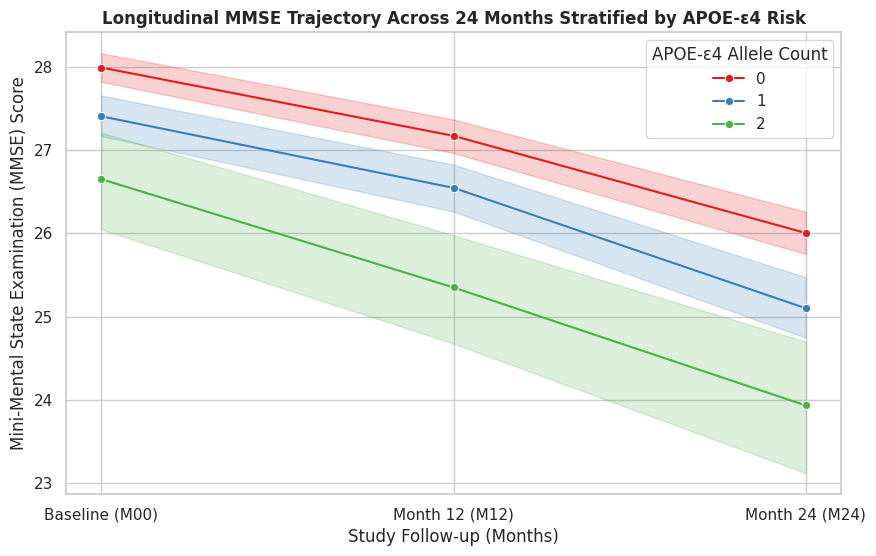

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Melt DataFrame for longitudinal plotting
df_long = pd.melt(
    df_adni,
    id_vars=['Patient_ID', 'APOE4_Carriers', 'Conversion_Status'],
    value_vars=['MMSE_Baseline', 'MMSE_Month12', 'MMSE_Month24'],
    var_name='Timepoint',
    value_name='MMSE_Score'
)

# Map timepoints to numeric months for plotting
timepoint_map = {'MMSE_Baseline': 0, 'MMSE_Month12': 12, 'MMSE_Month24': 24}
df_long['Month'] = df_long['Timepoint'].map(timepoint_map)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_long,
    x='Month',
    y='MMSE_Score',
    hue='APOE4_Carriers',
    palette='Set1',
    marker='o',
    err_style='band'
)

plt.title('Longitudinal MMSE Trajectory Across 24 Months Stratified by APOE-ε4 Risk', fontweight='bold')
plt.xlabel('Study Follow-up (Months)')
plt.ylabel('Mini-Mental State Examination (MMSE) Score')
plt.xticks([0, 12, 24], ['Baseline (M00)', 'Month 12 (M12)', 'Month 24 (M24)'])
plt.legend(title='APOE-ε4 Allele Count')
plt.show()

<lifelines.CoxPHFitter: fitted with 500 total observations, 297 right-censored observations>
             duration col = 'Followup_Months'
                event col = 'Conversion_Status'
      baseline estimation = breslow
   number of observations = 500
number of events observed = 203
   partial log-likelihood = -1109.04
         time fit was run = 2026-08-03 05:43:11 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
Age                  -0.03      0.97      0.01           -0.06           -0.01                0.94                0.99
APOE4_Carriers        0.80      2.23      0.11            0.60            1.01                1.82                2.75
Hippocampus_Vol_Base -0.60      0.55      0.09           -0.78           -0.42                0.46                0.66
Ventricles_Vol_Base  -0.01      0.99      0.01           -0.03            0.02                0.97                1.02
MMSE_Baseline        -0.16      0.85      0.04           -0.24           -0.08                0.78                0.92
MMSE_Decline_Rate     4.76    117.13      0.80            3.19            6.34               24.18              567.37

                      cmp to     z      p  -log2(p)
covariate                                          
Age                     0.00 -2.46   0.01      6.19
APOE4_Carriers          0.00  7.61 <0.005     45.07
Hippocampus_Vol_Base    0.00 -6.47 <0.005     33.29
Ventricles_Vol_Base     0.00 -0.68   0.50      1.00
MMSE_Baseline           0.00 -3.92 <0.005     13.44
MMSE_Decline_Rate       0.00  5.92 <0.005     28.19
---
Concordance = 0.78
Partial AIC = 2230.09
log-likelihood ratio test = 208.97 on 6 df
-log2(p) of ll-ratio test = 138.29

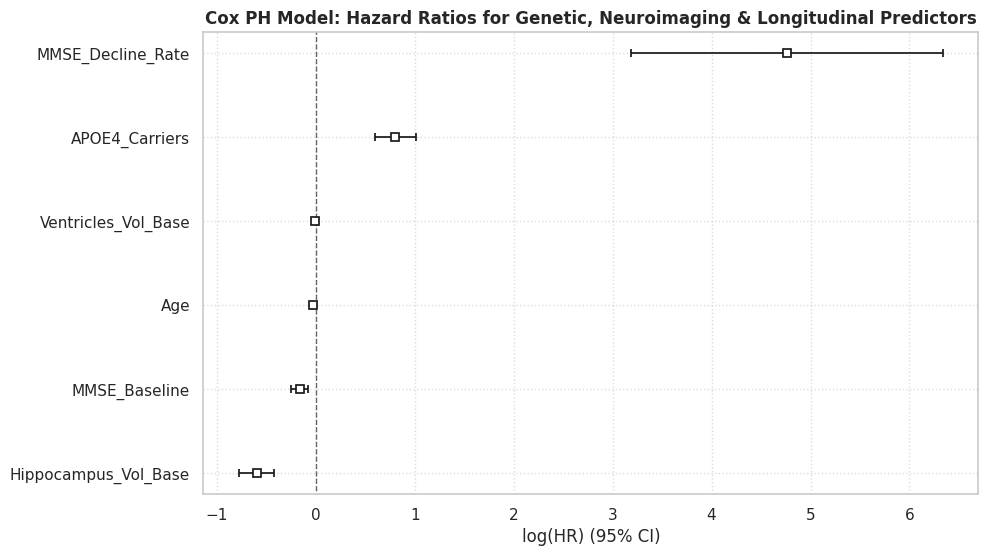

In [3]:
import matplotlib.pyplot as plt

!pip install lifelines
from lifelines import CoxPHFitter

# 1. Feature Engineering: Cognitive Decline Slope
df_adni['MMSE_Decline_Rate'] = (df_adni['MMSE_Baseline'] - df_adni['MMSE_Month24']) / 24.0

# 2. Select Features for Survival Modeling
cox_features = [
    'Age', 'APOE4_Carriers', 'Hippocampus_Vol_Base',
    'Ventricles_Vol_Base', 'MMSE_Baseline', 'MMSE_Decline_Rate',
    'Followup_Months', 'Conversion_Status'
]

df_cox = df_adni[cox_features].copy()

# 3. Fit Multivariable Cox PH Model
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='Followup_Months', event_col='Conversion_Status')

# Display Statistical Summary
cph.print_summary()

# Plot Hazard Ratios
plt.figure(figsize=(10, 6))
cph.plot()
plt.title('Cox PH Model: Hazard Ratios for Genetic, Neuroimaging & Longitudinal Predictors', fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()


--- Model Evaluation ---
Best RSF Parameters: {'max_depth': 8, 'min_samples_leaf': 10, 'n_estimators': 50}
Tuned 5-Fold RSF C-Index: 0.755


ExactExplainer explainer: 501it [03:55,  2.08it/s]
/tmp/ipykernel_3587/3357946561.py:36: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_adni)


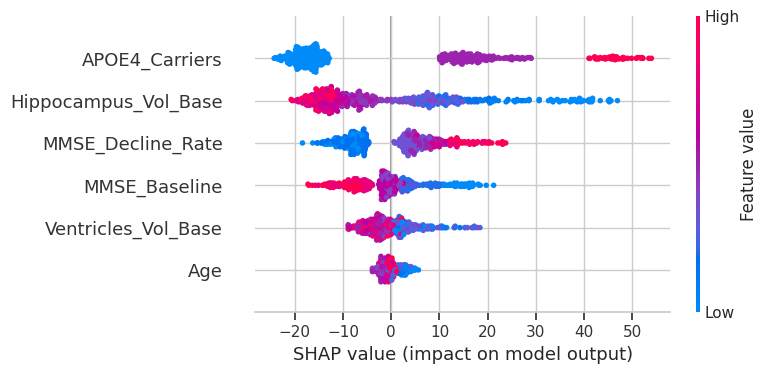

In [6]:
!pip install scikit-survival
import shap
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import GridSearchCV

# 1. Prepare ML Feature Matrix and Structured Target
X_adni = df_cox.drop(columns=['Followup_Months', 'Conversion_Status'])
y_adni = np.array(
    [(bool(status), time) for status, time in zip(df_cox['Conversion_Status'], df_cox['Followup_Months'])],
    dtype=[('Status', '?'), ('Time', '<f8')]
)

# 2. Hyperparameter Tuning using 5-Fold Cross-Validation
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 8],
    'min_samples_leaf': [5, 10]
}

rsf_base = RandomSurvivalForest(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rsf_base, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_adni, y_adni)

print("\n--- Model Evaluation ---")
print(f"Best RSF Parameters: {grid_search.best_params_}")
print(f"Tuned 5-Fold RSF C-Index: {grid_search.best_score_:.3f}")

# 3. SHAP Feature Attribution Analysis
best_rsf = grid_search.best_estimator_
# Use shap.Explainer for scikit-survival models as TreeExplainer is not directly supported.
# Pass the predict method of the model and the background data.
explainer = shap.Explainer(best_rsf.predict, X_adni)
shap_values = explainer(X_adni) # Call the explainer to get SHAP values

# Plot SHAP Summary
shap.summary_plot(shap_values, X_adni)